In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('heatwave_thermal_stress_dataset.csv', parse_dates=['date'])

# Basic look
df.head()

,date,temperature_c,humidity_pct,wind_speed_kmh,solar_radiation_w_m2,pressure_hpa,rainfall_mm,heat_index_c,wbgt_c,apparent_temperature_c,thermal_stress_score,thermal_stress_level,heatwave
0,2020-01-01 00:00:00,37.5,32.6,4.3,423.0,1018.7,0.2,38.6,35.3,39.6,27.41,Low,0
1,2020-01-01 06:00:00,33.0,34.2,6.1,599.0,1007.5,0.3,34.0,31.5,33.5,26.78,Low,0
2,2020-01-01 12:00:00,38.5,54.6,3.4,777.0,1000.4,2.5,40.8,37.3,46.1,37.00,Moderate,0
3,2020-01-01 18:00:00,44.7,41.5,7.1,620.0,991.8,0.4,45.9,42.3,52.2,33.86,Moderate,1
4,2020-01-02 00:00:00,32.4,38.6,12.8,623.0,992.7,0.5,32.8,31.1,32.1,26.52,Low,0


In [3]:
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (5000, 13)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    5000 non-null   datetime64[us]
 1   temperature_c           5000 non-null   float64       
 2   humidity_pct            5000 non-null   float64       
 3   wind_speed_kmh          5000 non-null   float64       
 4   solar_radiation_w_m2    5000 non-null   float64       
 5   pressure_hpa            5000 non-null   float64       
 6   rainfall_mm             5000 non-null   float64       
 7   heat_index_c            5000 non-null   float64       
 8   wbgt_c                  5000 non-null   float64       
 9   apparent_temperature_c  5000 non-null   float64       
 10  thermal_stress_score    5000 non-null   float64       
 11  thermal_stress_level    5000 non-null   str           
 12  heatwave                500

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,5000,2021-09-16 21:00:00,2020-01-01 00:00:00,2020-11-08 10:30:00,2021-09-16 21:00:00,2022-07-26 07:30:00,2023-06-03 18:00:00,NaN
temperature_c,5000.0,34.0405,18.0,29.4,34.1,38.7,50.0,6.82577
humidity_pct,5000.0,57.1116,20.0,38.9,56.9,75.4,95.0,21.41587
wind_speed_kmh,5000.0,11.07044,0.1,5.7,9.5,14.8,35.0,7.121865
solar_radiation_w_m2,5000.0,549.6804,50.0,377.0,548.0,721.0,1100.0,241.990918
pressure_hpa,5000.0,1005.0218,970.0,998.2,1005.1,1011.6,1037.2,9.820007
rainfall_mm,5000.0,1.49992,0.0,0.4,1.0,2.1,10.8,1.484105
heat_index_c,5000.0,35.5678,15.4,30.8,35.7,40.2,54.0,6.948608
wbgt_c,5000.0,33.1852,17.3,28.9,33.3,37.3,49.3,6.188225
apparent_temperature_c,5000.0,38.53042,9.5,30.3,37.8,45.6,82.1,11.679253


In [7]:
print("Thermal Stress Level counts:")
print(df['thermal_stress_level'].value_counts())

print("\nHeatwave flag counts:")
print(df['heatwave'].value_counts())

Thermal Stress Level counts:
thermal_stress_level
Moderate    2570
Low         1442
High         980
Extreme        8
Name: count, dtype: int64

Heatwave flag counts:
heatwave
0    4165
1     835
Name: count, dtype: int64


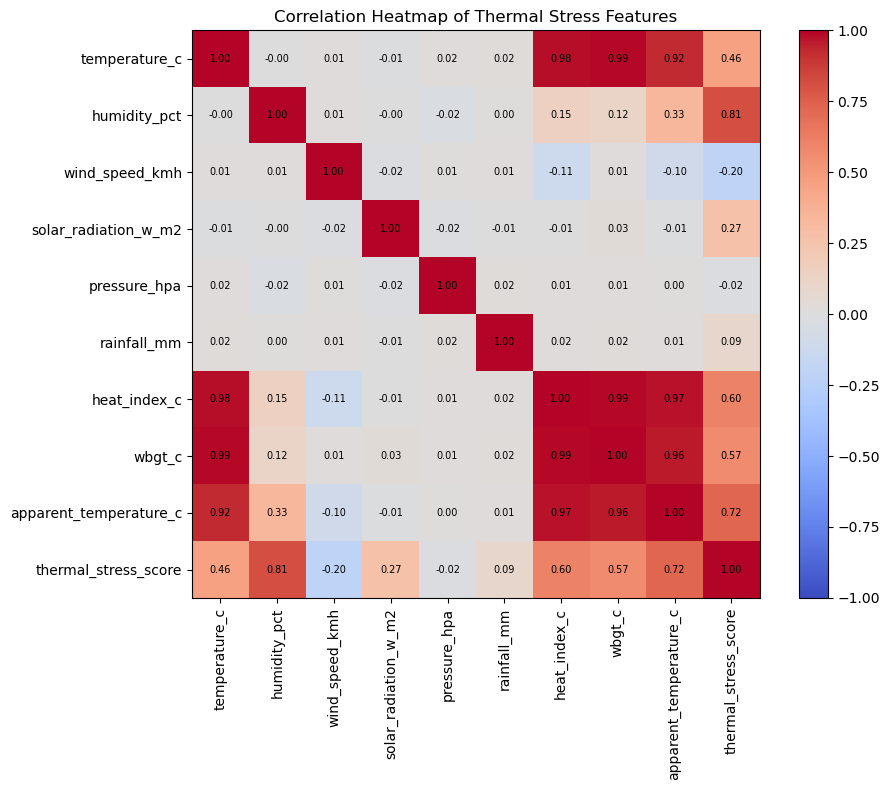

In [8]:
num_cols = ['temperature_c','humidity_pct','wind_speed_kmh','solar_radiation_w_m2',
            'pressure_hpa','rainfall_mm','heat_index_c','wbgt_c',
            'apparent_temperature_c','thermal_stress_score']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=7)

plt.colorbar(im)
plt.title('Correlation Heatmap of Thermal Stress Features')
plt.tight_layout()
plt.show()

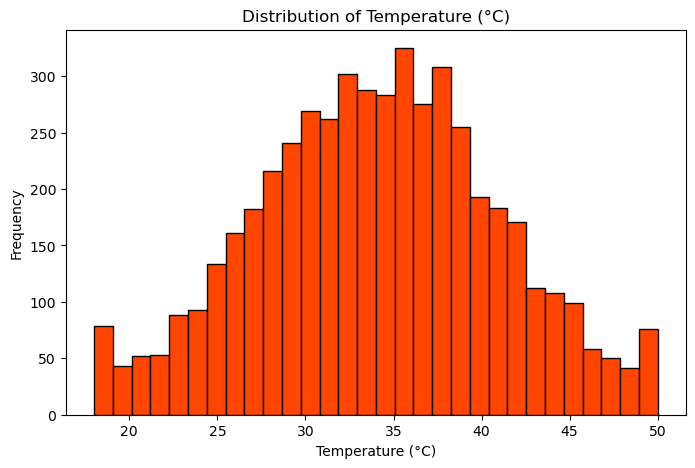

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['temperature_c'], bins=30, color='orangered', edgecolor='black')
plt.title('Distribution of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

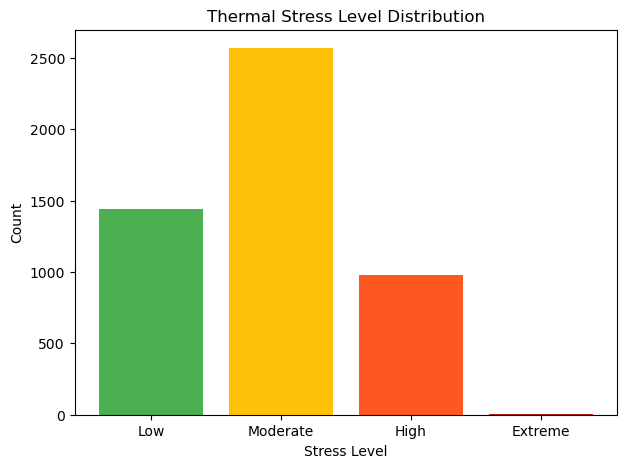

In [10]:
level_order = ['Low','Moderate','High','Extreme']
counts = df['thermal_stress_level'].value_counts().reindex(level_order)

plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values, color=['#4CAF50','#FFC107','#FF5722','#B71C1C'])
plt.title('Thermal Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

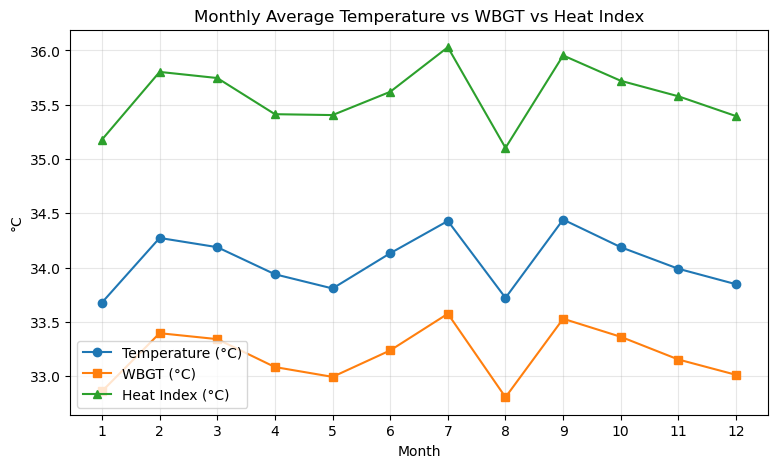

In [44]:
#monthly = df.groupby('month')[['temperature_c','wbgt_c','heat_index_c']].mean()

#plt.figure(figsize=(9,5))
#plt.plot(monthly.index, monthly['temperature_c'], marker='o', label='Temperature (°C)')
#plt.plot(monthly.index, monthly['wbgt_c'], marker='s', label='WBGT (°C)')
#plt.plot(monthly.index, monthly['heat_index_c'], marker='^', label='Heat Index (°C)')
#plt.xticks(range(1,13))
#plt.xlabel('Month')
#plt.ylabel('°C')
#plt.title('Monthly Average Temperature vs WBGT vs Heat Index')
#plt.legend()
#plt.grid(alpha=0.3)
#plt.show()

# Assuming 'date' is your datetime column name
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

monthly = df.groupby('month')[['temperature_c', 'wbgt_c', 'heat_index_c']].mean()

plt.figure(figsize=(9, 5))
plt.plot(monthly.index, monthly['temperature_c'], marker='o', label='Temperature (°C)')
plt.plot(monthly.index, monthly['wbgt_c'], marker='s', label='WBGT (°C)')
plt.plot(monthly.index, monthly['heat_index_c'], marker='^', label='Heat Index (°C)')
plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('°C')
plt.title('Monthly Average Temperature vs WBGT vs Heat Index')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

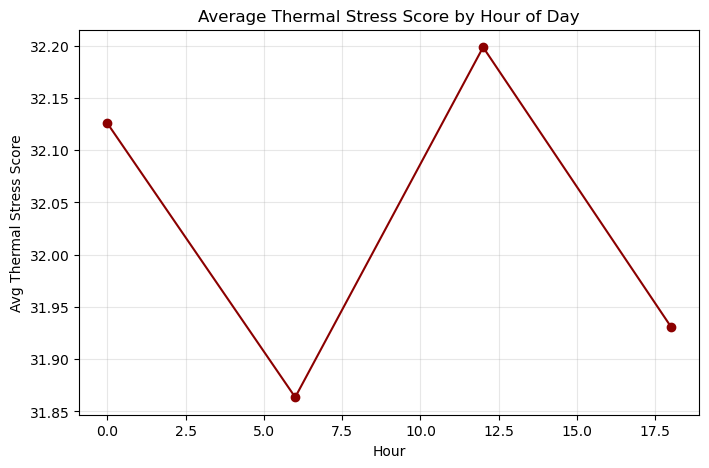

In [48]:
#hourly = df.groupby('hour')['thermal_stress_score'].mean()

#plt.figure(figsize=(8,5))
#plt.plot(hourly.index, hourly.values, marker='o', color='darkred')
#plt.title('Average Thermal Stress Score by Hour of Day')
#plt.xlabel('Hour')
#plt.ylabel('Avg Thermal Stress Score')
#plt.grid(alpha=0.3)
#plt.show()

# 'date' column se 'hour' extract karein
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour

# Hourly mean calculate karein
hourly = df.groupby('hour')['thermal_stress_score'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(hourly.index, hourly.values, marker='o', color='darkred')
plt.title('Average Thermal Stress Score by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Thermal Stress Score')
plt.grid(alpha=0.3)
plt.show()



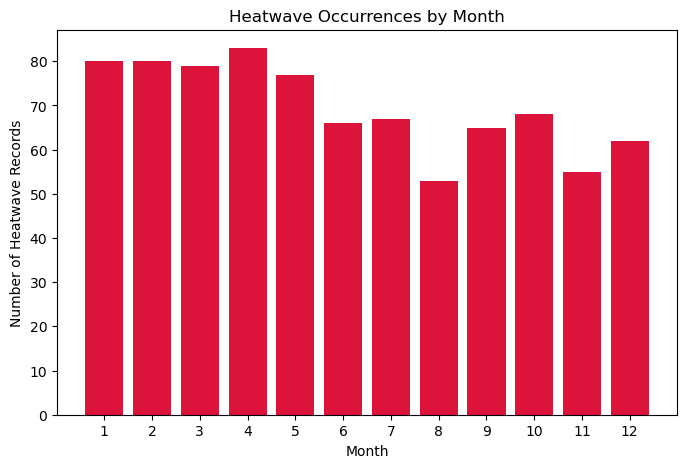

In [45]:
heatwave_by_month = df.groupby('month')['heatwave'].sum()

plt.figure(figsize=(8,5))
plt.bar(heatwave_by_month.index, heatwave_by_month.values, color='crimson')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Number of Heatwave Records')
plt.title('Heatwave Occurrences by Month')
plt.show()

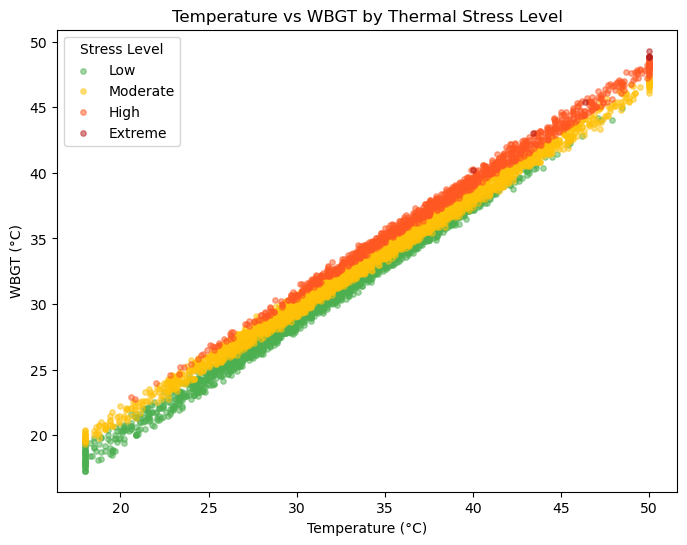

In [42]:
colors = {'Low':'#4CAF50','Moderate':'#FFC107','High':'#FF5722','Extreme':'#B71C1C'}

plt.figure(figsize=(8,6))
for level, color in colors.items():
    subset = df[df['thermal_stress_level'] == level]
    plt.scatter(subset['temperature_c'], subset['wbgt_c'],
                label=level, color=color, alpha=0.5, s=15)

plt.xlabel('Temperature (°C)')
plt.ylabel('WBGT (°C)')
plt.title('Temperature vs WBGT by Thermal Stress Level')
plt.legend(title='Stress Level')
plt.show()

C:\Users\Aryan Tomar\AppData\Local\Temp\ipykernel_11764\3384804763.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_level, labels=level_order)


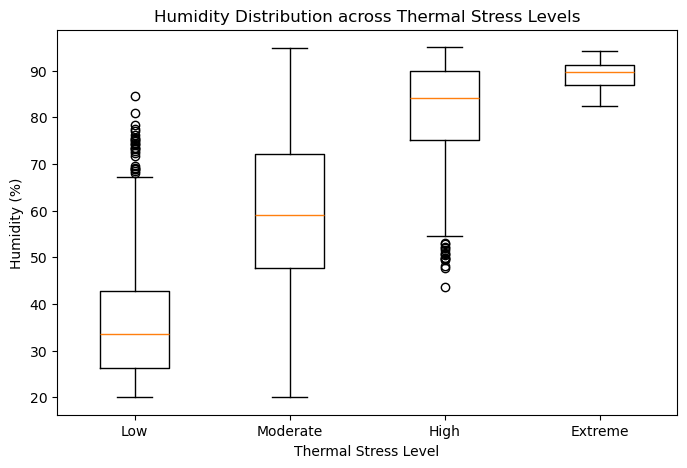

In [43]:
data_by_level = [df[df['thermal_stress_level']==lvl]['humidity_pct'] for lvl in level_order]

plt.figure(figsize=(8,5))
plt.boxplot(data_by_level, labels=level_order)
plt.title('Humidity Distribution across Thermal Stress Levels')
plt.xlabel('Thermal Stress Level')
plt.ylabel('Humidity (%)')
plt.show()

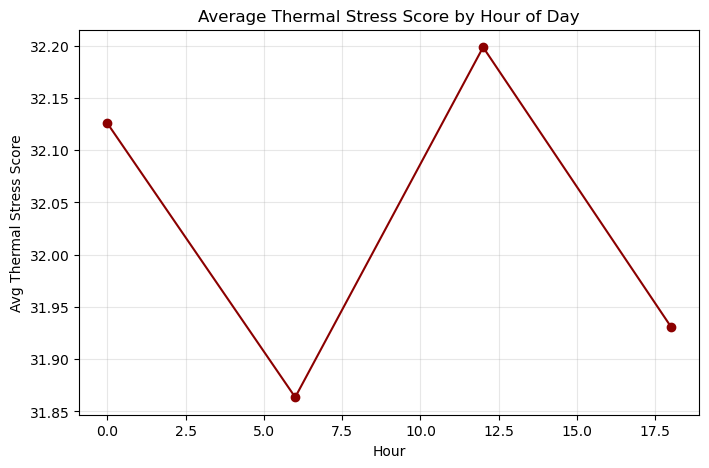

In [47]:
# 'date' column se 'hour' extract karein
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour

# Hourly mean calculate karein
hourly = df.groupby('hour')['thermal_stress_score'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(hourly.index, hourly.values, marker='o', color='darkred')
plt.title('Average Thermal Stress Score by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Thermal Stress Score')
plt.grid(alpha=0.3)
plt.show()